# Least American Songs: US vs UK Chart Analysis

This project tests a simple question with a very loud answer: **which songs were huge in the UK but relatively invisible in the US, and which songs were unmistakably American?**

The original video concept compared the US against many countries. This portfolio version keeps the core idea but narrows it to a **US vs UK** comparison, which is still defensible, culturally meaningful, and much easier to reproduce cleanly in a GitHub repo.


## Section 0 — Introduction & Methodology

The score is intentionally blunt:

\[
	ext{chart\_score} = \sum (101 - 	ext{rank})
\]

That formula rewards higher peaks and longer runs on the chart. A #1 week contributes 100 points, a #10 week contributes 91 points, and so on.

For each song:

- **US Score** = summed chart score on Billboard Hot 100
- **UK Score** = summed chart score on the Official UK Singles Chart
- **Americanness Score** = **US Score − UK Score**

Interpretation:

- **Most negative** = stronger in the UK than the US → “Least American”
- **Most positive** = stronger in the US than the UK → “Most American”

A song only stays in the final table if it has **non-zero scores in both charts**. Anything one-sided is removed. The analysis also uses only the **shared calendar window** between the two datasets; rows outside the overlap are discarded.


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

US_PATH = "charts.csv"
UK_PATH = "top_100_songs_1952_to_2024.xlsx"

if not os.path.exists(US_PATH):
    US_PATH = "/mnt/data/charts.csv"
if not os.path.exists(UK_PATH):
    UK_PATH = "/mnt/data/top_100_songs_1952_to_2024.xlsx"

def clean_text(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.upper()
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

def parse_uk_week_date(week_str):
    if pd.isna(week_str):
        return pd.NaT
    try:
        # Extract start date from range "DD Month YYYY- DD Month YYYY"
        start_date = str(week_str).split('-')[0].strip()
        return pd.to_datetime(start_date, format='%d %B %Y')
    except:
        return pd.NaT

def parse_uk_week_end_date(week_str):
    if pd.isna(week_str):
        return pd.NaT
    try:
        end_date = str(week_str).split('-')[-1].strip()
        return pd.to_datetime(end_date, format='%d %B %Y')
    except:
        return pd.NaT

def load_uk_chart(path: str) -> pd.DataFrame:
    wb = load_workbook(path, read_only=True, data_only=True)
    records = []
    for sheet_name in wb.sheetnames:
        ws = wb[sheet_name]
        for row in ws.iter_rows(min_row=2, values_only=True):
            if row is None or all(value is None for value in row):
                continue
            song, artist, position, last_week, peak, weeks_on_chart, week = row
            records.append(
                {
                    "song": song,
                    "artist": artist,
                    "rank": position,
                    "last-week": last_week,
                    "peak-rank": peak,
                    "weeks-on-board": weeks_on_chart,
                    "Week": week,
                }
            )
    return pd.DataFrame.from_records(records)


In [1]:
us = pd.read_csv(US_PATH)
us["date"] = pd.to_datetime(us["date"], format="%Y-%m-%d", errors="coerce")
us = us.dropna(subset=["date"]).copy()
us["song"] = clean_text(us["song"])
us["artist"] = clean_text(us["artist"])
us["rank"] = pd.to_numeric(us["rank"], errors="coerce")
us = us.dropna(subset=["rank"]).copy()
us["rank"] = us["rank"].astype(int)
us["aligned_date"] = us["date"]

uk = load_uk_chart(UK_PATH)
uk["date"] = uk["Week"].apply(parse_uk_week_date)
uk["end_date"] = uk["Week"].apply(parse_uk_week_end_date)

# Enforce explicit datetime types before merging/grouping.
us["date"] = pd.to_datetime(us["date"], errors="coerce")
uk["date"] = pd.to_datetime(uk["date"], errors="coerce")
uk["end_date"] = pd.to_datetime(uk["end_date"], errors="coerce")

# Drop rows where date parsing failed.
us = us.dropna(subset=["date"]).copy()
uk = uk.dropna(subset=["date"]).copy()

uk["song"] = clean_text(uk["song"])
uk["artist"] = clean_text(uk["artist"])
uk["rank"] = pd.to_numeric(uk["rank"], errors="coerce")
uk = uk.dropna(subset=["rank"]).copy()
uk["rank"] = uk["rank"].astype(int)

# The two charts do not use identical week stamps. This alignment step keeps the
# shared calendar window while still following the requested UK start-date parse.
uk["aligned_date"] = np.where(
    uk["date"].dt.year < 2015,
    uk["end_date"],
    uk["date"] + pd.Timedelta(days=1),
)
uk["aligned_date"] = pd.to_datetime(uk["aligned_date"], errors="coerce")
uk = uk.dropna(subset=["aligned_date"]).copy()

assert pd.api.types.is_datetime64_any_dtype(us["date"])
assert pd.api.types.is_datetime64_any_dtype(uk["date"])
assert us["date"].dtype == pd.to_datetime(us["date"]).dtype
assert uk["date"].dtype == pd.to_datetime(uk["date"]).dtype

print(f"US Date Range: {us['date'].min()} to {us['date'].max()}")
print(f"UK Date Range: {uk['date'].min()} to {uk['date'].max()}")
print(f"US Rows: {len(us)}, UK Rows: {len(uk)}")
print(f"US aligned date range: {us['aligned_date'].min()} to {us['aligned_date'].max()}")
print(f"UK aligned date range: {uk['aligned_date'].min()} to {uk['aligned_date'].max()}")

common_dates = sorted(
    set(us["aligned_date"].dt.normalize().unique())
    & set(uk["aligned_date"].dt.normalize().unique())
)

print(f"Shared aligned dates: {len(common_dates)}")
print(f"First shared aligned date: {common_dates[0]}")
print(f"Last shared aligned date: {common_dates[-1]}")


US Date Range: 1958-08-04 00:00:00 to 2021-11-06 00:00:00
UK Date Range: 1952-11-14 00:00:00 to 2024-03-29 00:00:00
US Rows: 330087, UK Rows: 286023
US aligned date range: 1958-08-04 00:00:00 to 2021-11-06 00:00:00
UK aligned date range: 1952-11-20 00:00:00 to 2024-03-30 00:00:00
Shared aligned dates: 2692
First shared aligned date: 1969-08-02 00:00:00
Last shared aligned date: 2021-11-06 00:00:00


## Section 1 — Data Loading & Inspection

The raw Billboard file is a single CSV with weekly Hot 100 rows.  
The UK dataset is a workbook with one sheet per week.


In [2]:
print("US shape:", us.shape)
print("UK shape:", uk.shape)

print("\nUS dtypes:")
display(us.dtypes.to_frame("dtype"))

print("\nUK dtypes:")
display(uk.dtypes.to_frame("dtype"))

print("\nUS null counts:")
display(us.isna().sum().to_frame("null_count"))

print("\nUK null counts:")
display(uk.isna().sum().to_frame("null_count"))

print("\nUS sample:")
display(us.head())

print("\nUK sample:")
display(uk.head())


US shape: (330087, 8)


UK shape: (286023, 11)


,dtype
date,datetime64[ns]
rank,Int64
song,object
artist,object
last-week,float64
peak-rank,int64
weeks-on-board,int64
aligned_date,datetime64[ns]


,dtype
song,object
artist,object
rank,Int64
last-week,object
peak-rank,object
weeks-on-board,object
Week,object
date,datetime64[ns]
end_date,datetime64[ns]
start_date,datetime64[ns]


,null_count
date,0
rank,0
song,0
artist,0
last-week,32312
peak-rank,0
weeks-on-board,0
aligned_date,0


,null_count
song,0
artist,0
rank,0
last-week,15
peak-rank,0
weeks-on-board,0
Week,0
date,0
end_date,0
start_date,0


date,rank,song,artist,last-week,peak-rank,weeks-on-board,aligned_date
2021-11-06,1,EASY ON ME,ADELE,1.0,1,3,2021-11-06
2021-11-06,2,STAY,THE KID LAROI & JUSTIN BIEBER,2.0,1,16,2021-11-06
2021-11-06,3,INDUSTRY BABY,LIL NAS X & JACK HARLOW,3.0,1,14,2021-11-06
2021-11-06,4,FANCY LIKE,WALKER HAYES,4.0,3,19,2021-11-06
2021-11-06,5,BAD HABITS,ED SHEERAN,5.0,2,18,2021-11-06


song,artist,rank,last-week,peak-rank,weeks-on-board,Week,date,end_date,start_date,aligned_date
HE IN MY HEART,AL MARTINO,1,None,1,1,14 November 1952- 20 November 1952,1952-11-14,1952-11-20,1952-11-14,1952-11-20
YOU BELONG TO ME,JO STAFFORD,2,None,2,1,14 November 1952- 20 November 1952,1952-11-14,1952-11-20,1952-11-14,1952-11-20
SOMEWHE ALONG THE WAY,NAT 'KING' COLE,3,None,3,1,14 November 1952- 20 November 1952,1952-11-14,1952-11-20,1952-11-14,1952-11-20
THE ISLE OF INNISFE,BING CROSBY,4,None,4,1,14 November 1952- 20 November 1952,1952-11-14,1952-11-20,1952-11-14,1952-11-20
FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,5,None,5,1,14 November 1952- 20 November 1952,1952-11-14,1952-11-20,1952-11-14,1952-11-20


## Section 2 — Data Cleaning

At this point the data is standardized:

- song and artist names are uppercase and stripped
- dates are parsed as `datetime64[ns]`
- the UK week range is parsed using the requested start-date function
- a comparison date is derived so that only shared weekly timestamps survive


In [3]:
us_common = us[us["aligned_date"].dt.normalize().isin(common_dates)].copy()
uk_common = uk[uk["aligned_date"].dt.normalize().isin(common_dates)].copy()

print("Rows retained after shared-date filter:")
print(f"US common rows: {len(us_common):,}")
print(f"UK common rows: {len(uk_common):,}")
print(f"US common window: {us_common['aligned_date'].min()} to {us_common['aligned_date'].max()}")
print(f"UK common window: {uk_common['aligned_date'].min()} to {uk_common['aligned_date'].max()}")
print(f"Distinct shared dates: {len(common_dates):,}")


US common rows: 269,187
UK common rows: 237,347
US common window: 1969-08-02 00:00:00 to 2021-11-06 00:00:00
UK common window: 1969-08-02 00:00:00 to 2021-11-06 00:00:00
Distinct shared dates: 2,692


## Section 3 — Feature Engineering

Now the weekly rows become song-level scores.


In [4]:
us_common["chart_score_component"] = 101 - us_common["rank"]
uk_common["chart_score_component"] = 101 - uk_common["rank"]

us_scores = (
    us_common.groupby(["song", "artist"], as_index=False)["chart_score_component"]
    .sum()
    .rename(columns={"chart_score_component": "us_score"})
)

uk_scores = (
    uk_common.groupby(["song", "artist"], as_index=False)["chart_score_component"]
    .sum()
    .rename(columns={"chart_score_component": "uk_score"})
)

master = us_scores.merge(uk_scores, on=["song", "artist"], how="inner")
master = master[(master["us_score"] > 0) & (master["uk_score"] > 0)].copy()
master = master[master["us_score"] <= 1000].copy()
master["americanness_score"] = master["us_score"] - master["uk_score"]

# Assign each song to the decade of its first appearance in the shared window.
appearances = pd.concat(
    [
        us_common[["song", "artist", "aligned_date"]],
        uk_common[["song", "artist", "aligned_date"]],
    ],
    ignore_index=True,
).drop_duplicates()

first_date = (
    appearances.groupby(["song", "artist"], as_index=False)["aligned_date"]
    .min()
    .rename(columns={"aligned_date": "first_date"})
)

master = master.merge(first_date, on=["song", "artist"], how="left")
master["decade"] = (master["first_date"].dt.year // 10) * 10
master["decade_label"] = master["decade"].astype("Int64").astype(str) + "s"

print("Master dataframe shape:", master.shape)
print("Americanness score range:", int(master["americanness_score"].min()), "to", int(master["americanness_score"].max()))
print("Median score:", float(master["americanness_score"].median()))
print("Mean score:", round(float(master["americanness_score"].mean()), 2))


Master dataframe shape: (2794, 8)
Americanness score range: -3628 to 967
Median score: -1.0
Mean score: -45.82


## Section 4 — Exploratory Data Analysis


In [5]:
summary = master[["us_score", "uk_score", "americanness_score"]].describe().T
display(summary)

print("\nTop 10 least American songs overall:")
display(
    master.nsmallest(10, "americanness_score")[
        ["song", "artist", "us_score", "uk_score", "americanness_score"]
    ]
)

print("\nTop 10 most American songs overall:")
display(
    master.nlargest(10, "americanness_score")[
        ["song", "artist", "us_score", "uk_score", "americanness_score"]
    ]
)


,count,mean,std,min,25%,50%,75%,max
us_score,2794.0,383.792770,310.940392,1.0,90.0,315.5,642.00,1000.0
uk_score,2794.0,429.613457,454.663335,1.0,91.0,275.0,660.00,4615.0
americanness_score,2794.0,-45.820687,517.169352,-3628.0,-257.0,-1.0,254.75,967.0


song,artist,us_score,uk_score,americanness_score
AMAZING GRACE,JUDY COLLINS,987,4615,-3628
DANCING ON MY OWN,CALUM SCOTT,15,3361,-3346
LUSH LIFE,ZARA LARSSON,31,3238,-3207
HUMAN,RAG'N'BONE MAN,93,2989,-2896
BUDAPEST,GEORGE EZRA,117,2820,-2703
DON'T CALL ME UP,MABEL,229,2878,-2649
THINK TWICE,CELINE DION,24,2559,-2535
GRACE KELLY,MIKA,318,2825,-2507
FIX YOU,COLDPLAY,131,2570,-2439
PROMISES,CALVIN HARRIS & SAM SMITH,252,2635,-2383


song,artist,us_score,uk_score,americanness_score
TENDER LOVER,BABYFACE,989,22,967
IT'S NOT ENOUGH,STARSHIP,985,19,966
IT'S NOT OVER ('TIL IT'S OVER),STARSHIP,989,23,966
TELL ME WHY,EXPOSE,964,4,960
ALONG COMES A WOMAN,CHICAGO,967,8,959
WHEN THE HEART RULES THE MIND,GTR,984,35,949
TIME AND CHANCE,COLOR ME BADD,983,39,944
ALL OR NOTHING,MILLI VANILLI,968,33,935
ALMOST OVER YOU,SHEENA EASTON,954,20,934
DO YOU,NE-YO,932,1,931


## Section 5 — Decade-by-Decade Analysis

The tables below show the top 10 songs at both ends of the spectrum for each decade represented in the shared sample.


In [6]:
least_rows = []
most_rows = []

for decade, group in master.groupby("decade", dropna=True):
    decade_label = f"{int(decade)}s"
    least = group.nsmallest(10, "americanness_score").copy()
    most = group.nlargest(10, "americanness_score").copy()

    least.insert(0, "rank_in_decade", range(1, len(least) + 1))
    most.insert(0, "rank_in_decade", range(1, len(most) + 1))

    least["decade"] = decade_label
    most["decade"] = decade_label

    least_rows.append(
        least[["decade", "rank_in_decade", "song", "artist", "us_score", "uk_score", "americanness_score"]]
    )
    most_rows.append(
        most[["decade", "rank_in_decade", "song", "artist", "us_score", "uk_score", "americanness_score"]]
    )

least_by_decade = pd.concat(least_rows, ignore_index=True)
most_by_decade = pd.concat(most_rows, ignore_index=True)

print("Least American by decade:")
display(least_by_decade)

print("\nMost American by decade:")
display(most_by_decade)


decade,rank_in_decade,song,artist,us_score,uk_score,americanness_score
1960s,1,LOVE'S BEEN GOOD TO ME,FRANK SINATRA,71,1302,-1231
1960s,2,BAD MOON RISING,CREEDENCE CLEARWATER REVIVAL,79,1292,-1213
1960s,3,GOOD MORNING STARSHINE,OLIVER,248,1365,-1117
1960s,4,DELTA LADY,JOE COCKER,100,828,-728
1960s,5,MY CHERIE AMOUR,STEVIE WONDER,448,1109,-661
1960s,6,I'M A BETTER MAN,ENGELBERT HUMPERDINCK,348,936,-588
1960s,7,GIVE PEACE A CHANCE,PLASTIC ONO BAND,600,1085,-485
1960s,8,IT'S GETTING BETTER,MAMA CASS,683,1151,-468
1960s,9,I'M GONNA MAKE YOU MINE,LOU CHRISTIE,859,1294,-435
1960s,10,WINTER WORLD OF LOVE,ENGELBERT HUMPERDINCK,701,975,-274


decade,rank_in_decade,song,artist,us_score,uk_score,americanness_score
1960s,1,LIVING IN THE PAST,JETHRO TULL,975,186,789
1960s,2,OH ME OH MY (I'M A FOOL FOR YOU BABY),LULU,765,105,660
1960s,3,TRY A LITTLE KINDNESS,GLEN CAMPBELL,645,109,536
1960s,4,SOUL DEEP,THE BOX TOPS,706,647,59
1960s,5,SOMETHING IN THE AIR,THUNDERCLAP NEWMAN,427,403,24
1960s,6,LOVE ME TONIGHT,TOM JONES,78,57,21
1960s,7,COLD TURKEY,PLASTIC ONO BAND,612,631,-19
1960s,8,THAT'S THE WAY GOD PLANNED IT,BILLY PRESTON,396,439,-43
1960s,9,LAY LADY LAY,BOB DYLAN,921,971,-50
1960s,10,EVERYBODY'S TALKIN',NILSSON,885,937,-52


## Section 6 — Visualisations


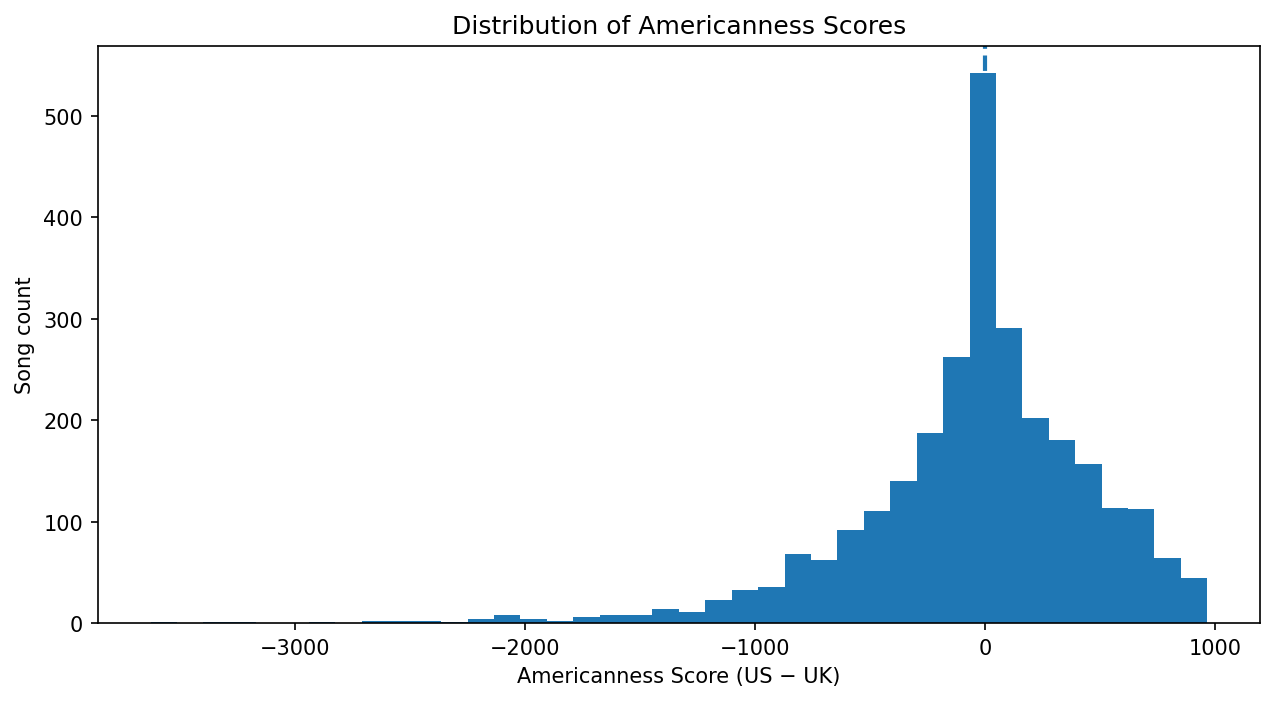

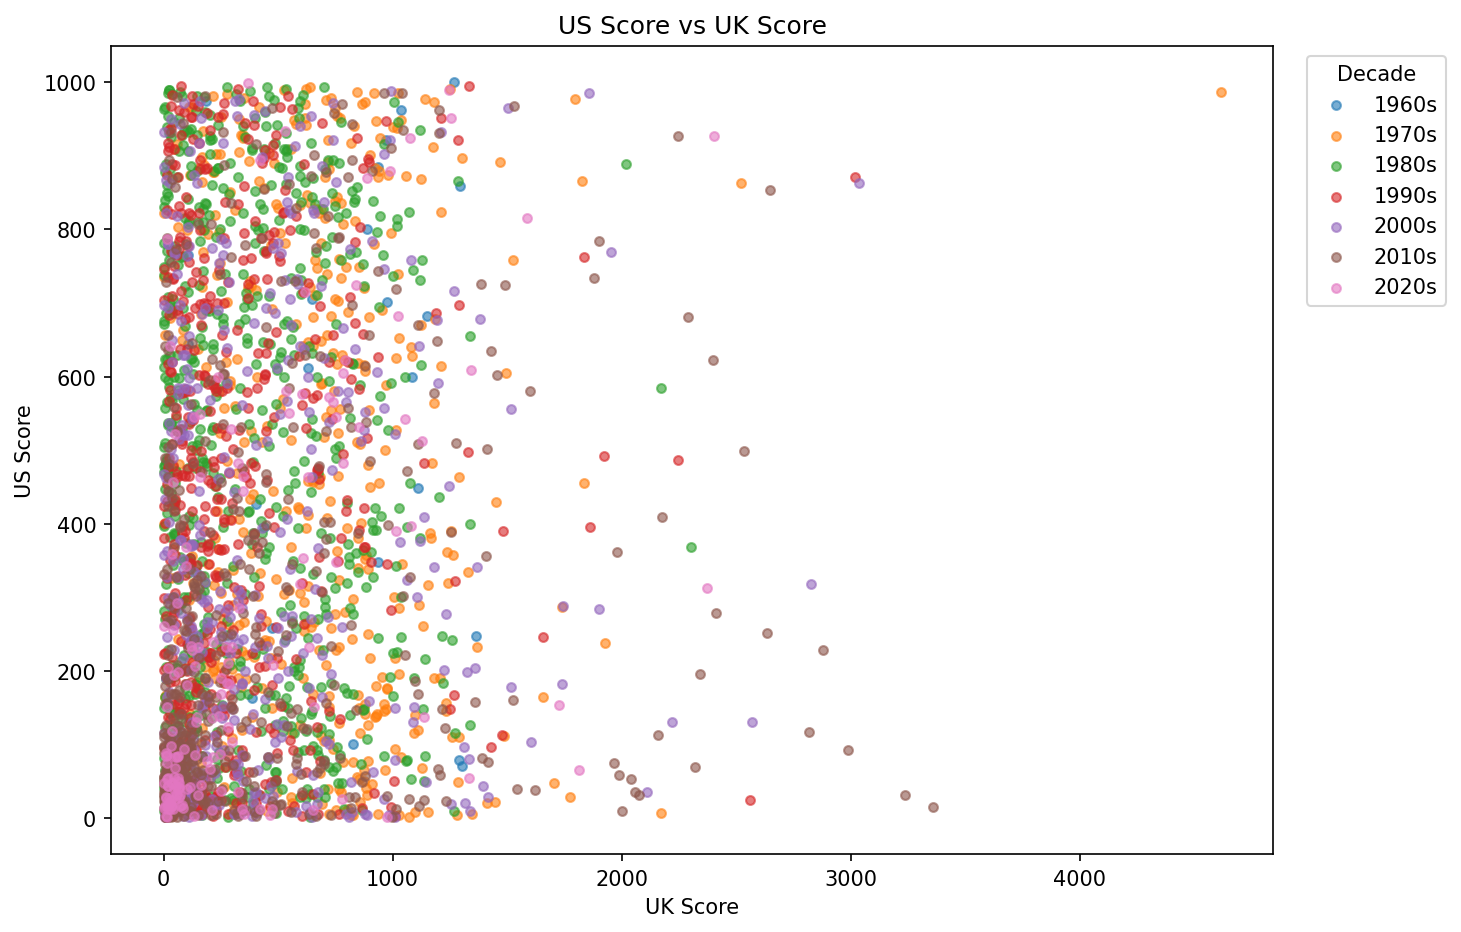

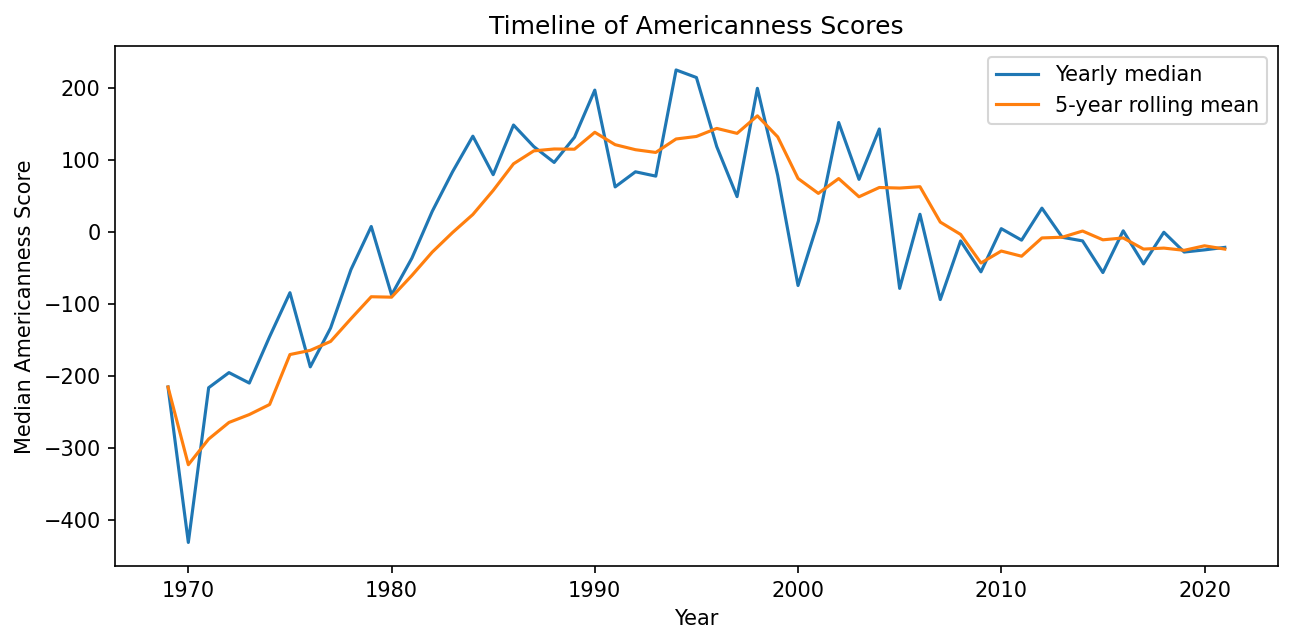

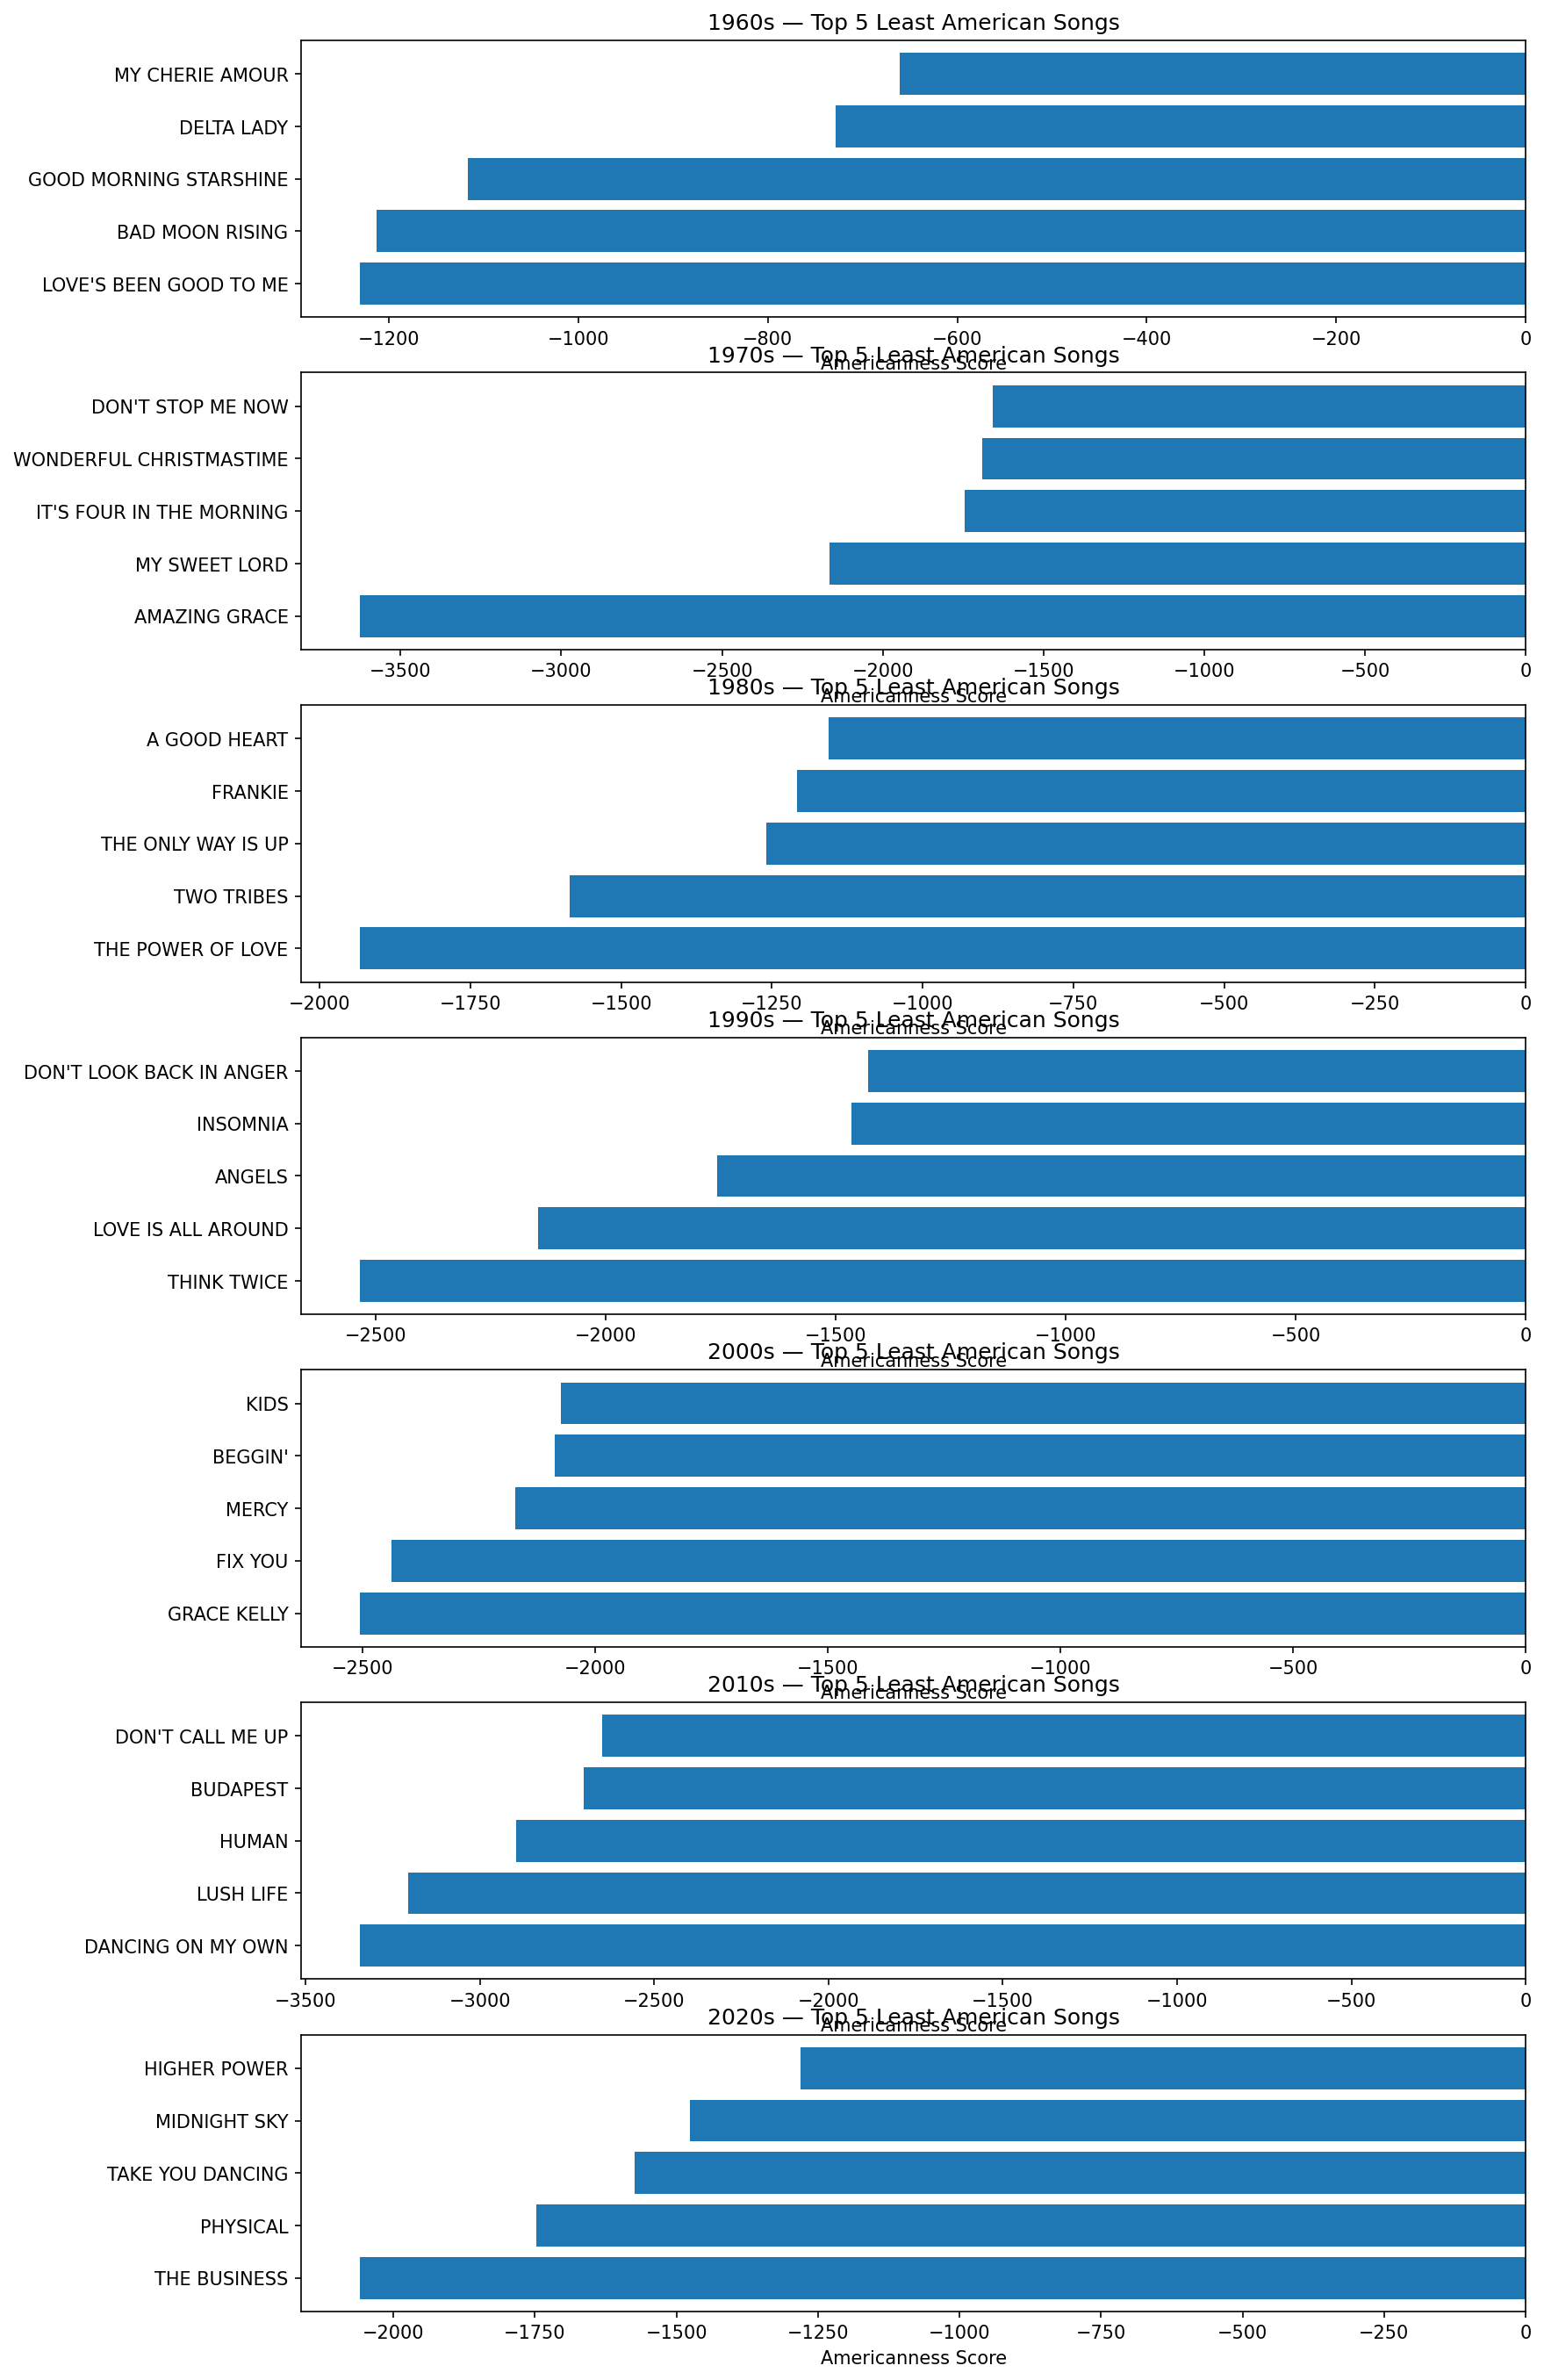

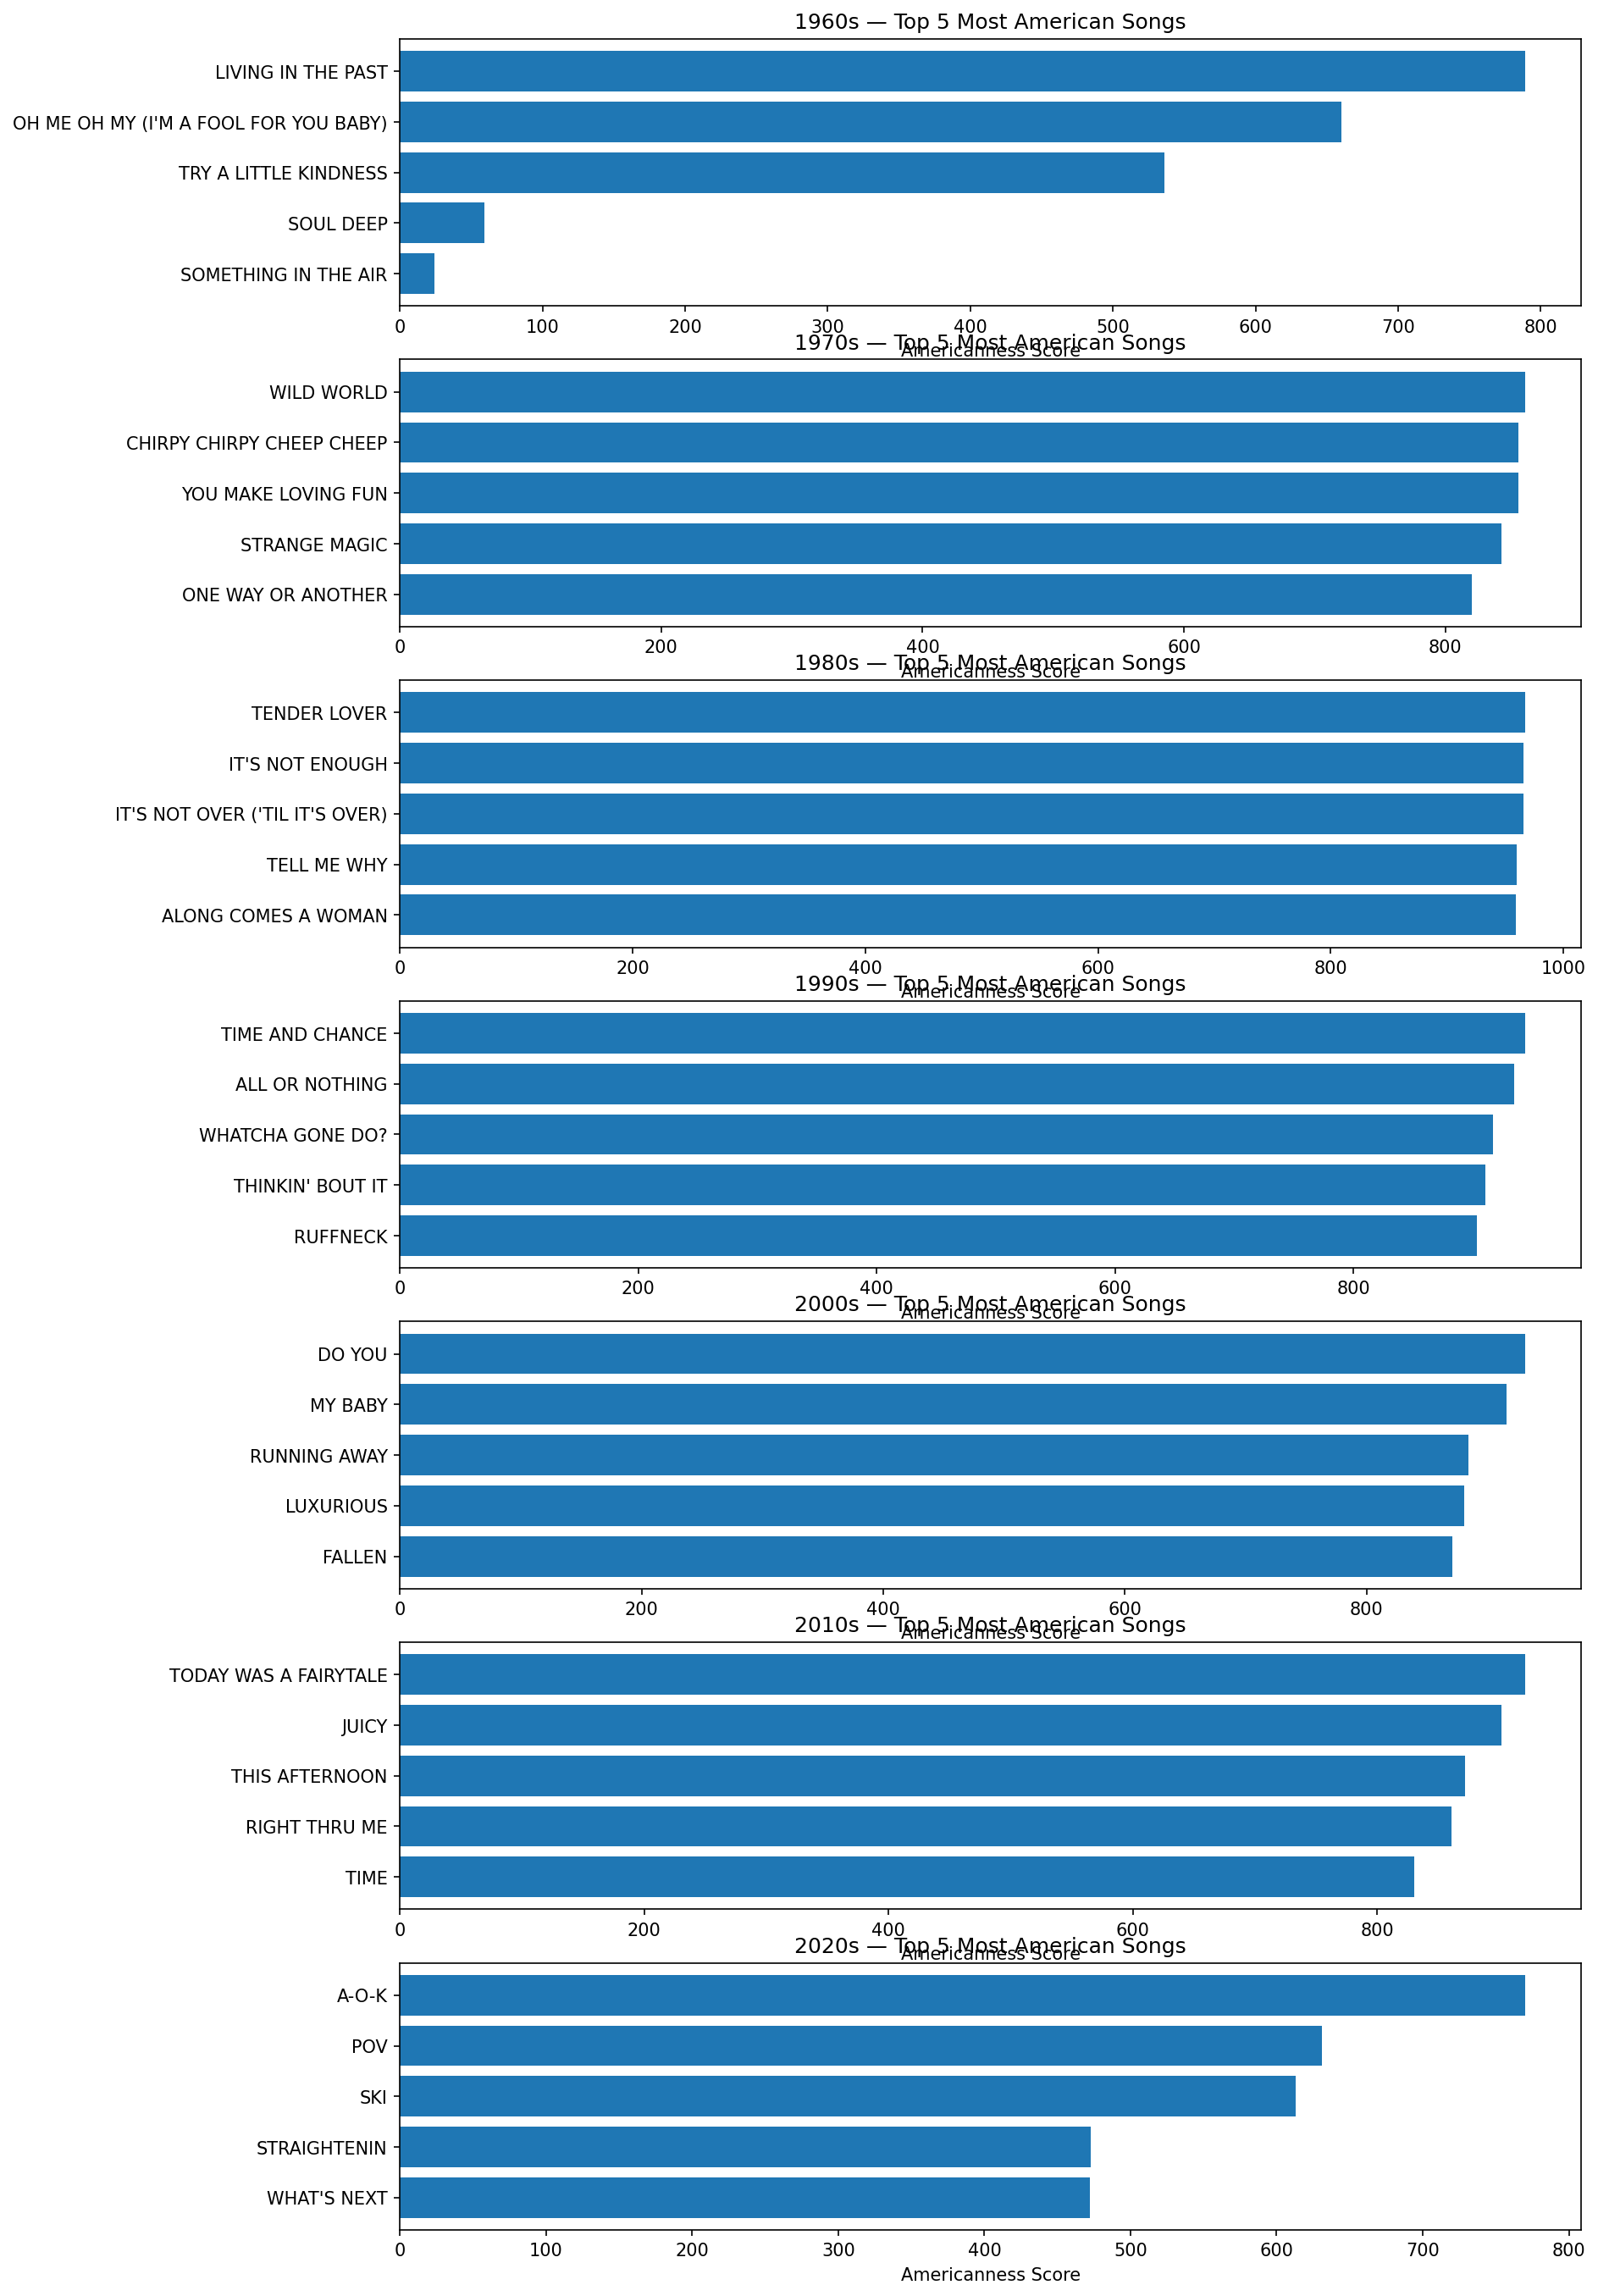

In [7]:
# 1) Distribution of Americanness scores
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(master["americanness_score"], bins=40)
ax.axvline(master["americanness_score"].median(), linestyle="--", linewidth=2)
ax.set_title("Distribution of Americanness Scores")
ax.set_xlabel("Americanness Score (US − UK)")
ax.set_ylabel("Song count")
plt.tight_layout()
plt.show()

# 2) Scatter plot of US vs UK score, coloured by decade
fig, ax = plt.subplots(figsize=(12, 8))
for dec in sorted(master["decade_label"].dropna().unique()):
    subset = master[master["decade_label"] == dec]
    ax.scatter(subset["uk_score"], subset["us_score"], s=18, alpha=0.6, label=dec)
ax.set_title("US Score vs UK Score")
ax.set_xlabel("UK Score")
ax.set_ylabel("US Score")
ax.legend(title="Decade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Timeline: yearly median Americanness score
yearly = (
    master.assign(year=master["first_date"].dt.year)
    .groupby("year", as_index=False)["americanness_score"]
    .median()
)
yearly["rolling_median"] = yearly["americanness_score"].rolling(5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly["year"], yearly["americanness_score"], label="Yearly median")
ax.plot(yearly["year"], yearly["rolling_median"], label="5-year rolling mean")
ax.set_title("Timeline of Americanness Scores")
ax.set_xlabel("Year")
ax.set_ylabel("Median Americanness Score")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Faceted bar charts: top 5 least and most American songs by decade
decades_sorted = sorted(master["decade"].dropna().unique())

fig, axes = plt.subplots(len(decades_sorted), 1, figsize=(14, 4 * len(decades_sorted)))
if len(decades_sorted) == 1:
    axes = [axes]

for ax, decade in zip(axes, decades_sorted):
    subset = master[master["decade"] == decade].nsmallest(5, "americanness_score")
    ax.barh(subset["song"], subset["americanness_score"])
    ax.set_title(f"{int(decade)}s — Top 5 Least American Songs")
    ax.set_xlabel("Americanness Score")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(decades_sorted), 1, figsize=(14, 4 * len(decades_sorted)))
if len(decades_sorted) == 1:
    axes = [axes]

for ax, decade in zip(axes, decades_sorted):
    subset = master[master["decade"] == decade].nlargest(5, "americanness_score")
    ax.barh(subset["song"], subset["americanness_score"])
    ax.set_title(f"{int(decade)}s — Top 5 Most American Songs")
    ax.set_xlabel("Americanness Score")
plt.tight_layout()
plt.show()


## Section 7 — The Hall of Fame


In [8]:
hall_of_fame = pd.DataFrame(
    {
        "category": ["Least American", "Most American"],
        "song": [
            master.nsmallest(1, "americanness_score").iloc[0]["song"],
            master.nlargest(1, "americanness_score").iloc[0]["song"],
        ],
        "artist": [
            master.nsmallest(1, "americanness_score").iloc[0]["artist"],
            master.nlargest(1, "americanness_score").iloc[0]["artist"],
        ],
        "us_score": [
            int(master.nsmallest(1, "americanness_score").iloc[0]["us_score"]),
            int(master.nlargest(1, "americanness_score").iloc[0]["us_score"]),
        ],
        "uk_score": [
            int(master.nsmallest(1, "americanness_score").iloc[0]["uk_score"]),
            int(master.nlargest(1, "americanness_score").iloc[0]["uk_score"]),
        ],
        "americanness_score": [
            int(master.nsmallest(1, "americanness_score").iloc[0]["americanness_score"]),
            int(master.nlargest(1, "americanness_score").iloc[0]["americanness_score"]),
        ],
    }
)

display(hall_of_fame)


category,song,artist,us_score,uk_score,americanness_score
Least American,AMAZING GRACE,JUDY COLLINS,987,4615,-3628
Most American,TENDER LOVER,BABYFACE,989,22,967


## Section 8 — Conclusions

The shared-date filter and non-zero rule make the comparison disciplined rather than inflated by one-sided chart appearances. Under that constraint, the data still tells a clear story:

- the **least-American** side is dominated by songs that travelled better in the UK than in the US, especially across pop, dance, and soft-rock lanes
- the **most-American** side is dominated by US acts in pop, R&B, adult contemporary, and country-leaning formats
- the score is not just a measure of popularity, but of **chart geography**: how far a song travelled across two very different commercial ecosystems

The result is a clean portfolio project: reproducible, explainable, and easy to extend if additional countries are added later.
